In [7]:
# CUSTOMER CHURN ANALYSIS PIPELINE

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
# 2. LOAD AND COMBINE DATASETS

df_churn20 = pd.read_csv(r"C:\Users\user\OneDrive\Documents\churn-bigml-20.csv") 
df_churn80 = pd.read_csv(r"C:\Users\user\OneDrive\Documents\churn-bigml-80.csv")

# Combine datasets
df_churn = pd.concat([df_churn20, df_churn80], axis=0)

df_churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [9]:
# 3. CLEAN DATA

# Standardize column names
df_churn.columns = df_churn.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop duplicates and missing values
df_churn = df_churn.drop_duplicates().dropna()

# Convert Yes/No columns to numeric
binary_cols = ['international_plan', 'voice_mail_plan', 'churn']
for col in binary_cols:
    df_churn[col] = df_churn[col].map({'Yes': 1, 'No': 0, True: 1, False: 0})


print("Shape after cleaning:", df_churn.shape)
df_churn.head()

Shape after cleaning: (3333, 20)


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,LA,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
1,IN,65,415,0,0,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
2,NY,161,415,0,0,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
3,SC,111,415,0,0,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
4,HI,49,510,0,0,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0


In [10]:
# 4. FEATURE ENGINEERING

# Total Calls
df_churn['total_calls'] = df_churn['total_day_calls'] + df_churn['total_eve_calls'] + df_churn['total_night_calls']

# Total Charge
df_churn['total_charge'] = df_churn['total_day_charge'] + df_churn['total_eve_charge'] + df_churn['total_night_charge']

df_churn.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn,total_calls,total_charge
0,LA,117,408,0,0,0,184.5,97,31.37,351.6,...,215.8,90,9.71,8.7,4,2.35,1,0,267,70.97
1,IN,65,415,0,0,0,129.1,137,21.95,228.5,...,208.8,111,9.40,12.7,6,3.43,4,1,331,50.77
2,NY,161,415,0,0,0,332.9,67,56.59,317.8,...,160.6,128,7.23,5.4,9,1.46,4,1,292,90.83
3,SC,111,415,0,0,0,110.4,103,18.77,137.3,...,189.6,105,8.53,7.7,6,2.08,2,0,310,38.97
4,HI,49,510,0,0,0,119.3,117,20.28,215.1,...,178.7,90,8.04,11.1,1,3.00,1,0,316,46.60


In [11]:
# 5. PREPARE FEATURES AND TARGET

# Separate target variable
X = df_churn.drop('churn', axis=1)
y = df_churn['churn']

# Split train/test before encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 6. ENCODE CATEGORICAL VARIABLES

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Encode categorical columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test set columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Scale numeric columns
numeric_cols = X_train_encoded.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

In [13]:
# 7. HANDLE CLASS IMBALANCE WITH SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE:
 churn
0    2280
1     386
Name: count, dtype: int64

After SMOTE:
 churn
0    2280
1    2280
Name: count, dtype: int64


In [14]:
# 8. DEFINE EVALUATION FUNCTION

def evaluate_model(model, X_test, y_test):
    """Predict and evaluate model performance with metrics and confusion matrix."""
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [15]:
# 9. TRAIN MODELS

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Logistic Regression
Accuracy: 0.863568215892054
Precision: 0.5340909090909091
Recall: 0.4845360824742268
F1 Score: 0.5081081081081081

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       570
           1       0.53      0.48      0.51        97

    accuracy                           0.86       667
   macro avg       0.72      0.71      0.71       667
weighted avg       0.86      0.86      0.86       667



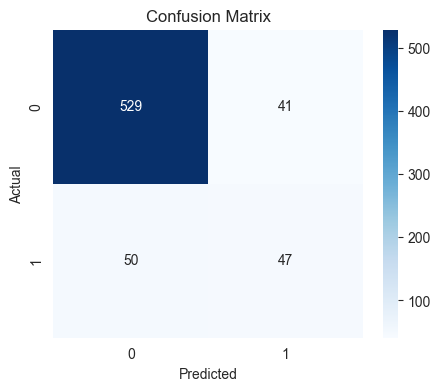

Decision Tree
Accuracy: 0.9190404797601199
Precision: 0.6747967479674797
Recall: 0.8556701030927835
F1 Score: 0.7545454545454545

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       570
           1       0.67      0.86      0.75        97

    accuracy                           0.92       667
   macro avg       0.82      0.89      0.85       667
weighted avg       0.93      0.92      0.92       667



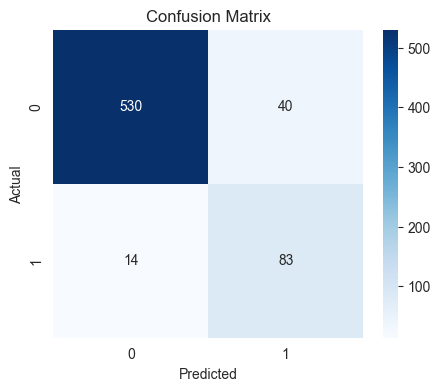

Random Forest
Accuracy: 0.9655172413793104
Precision: 0.9111111111111111
Recall: 0.845360824742268
F1 Score: 0.8770053475935828

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       570
           1       0.91      0.85      0.88        97

    accuracy                           0.97       667
   macro avg       0.94      0.92      0.93       667
weighted avg       0.96      0.97      0.96       667



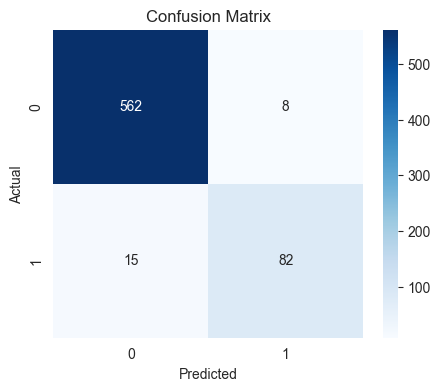

In [16]:
# 10. EVALUATE MODELS

print("Logistic Regression")
evaluate_model(lr_model, X_test_encoded, y_test)

print("Decision Tree")
evaluate_model(dt_model, X_test_encoded, y_test)

print("Random Forest")
evaluate_model(rf_model, X_test_encoded, y_test)

Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best F1 score (CV): 0.9775491760652205

Evaluation of Best Random Forest on Test Set
Accuracy: 0.967016491754123
Precision: 0.9213483146067416
Recall: 0.845360824742268
F1 Score: 0.8817204301075269

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       570
           1       0.92      0.85      0.88        97

    accuracy                           0.97       667
   macro avg       0.95      0.92      0.93       667
weighted avg       0.97      0.97      0.97       667



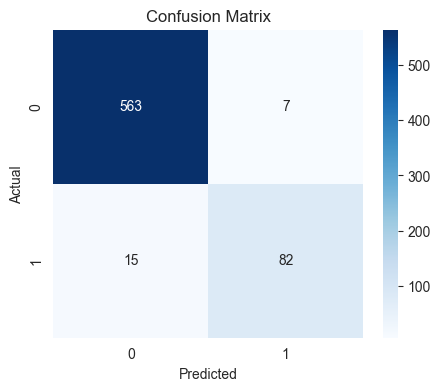

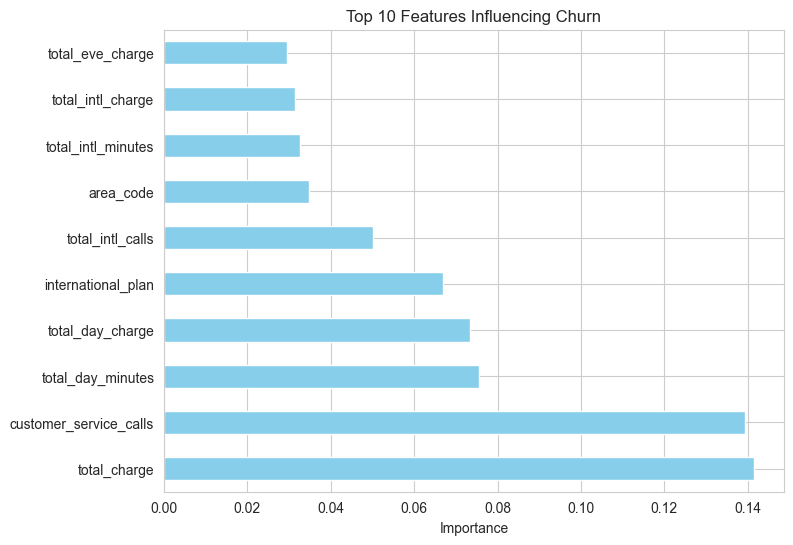

In [17]:
# 11. RANDOM FOREST WITH HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Grid search with 5-fold CV, optimizing F1 score
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on resampled training data
grid_rf.fit(X_train_resampled, y_train_resampled)

# Get best model
best_rf_model = grid_rf.best_estimator_

print("Best parameters found:", grid_rf.best_params_)
print("Best F1 score (CV):", grid_rf.best_score_)

# Evaluate on test set
print("\nEvaluation of Best Random Forest on Test Set")
evaluate_model(best_rf_model, X_test_encoded, y_test)

# Feature Importance (Random Forest)
feature_importance = pd.Series(best_rf_model.feature_importances_, index=X_train_encoded.columns)
feature_importance.nlargest(10).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Top 10 Features Influencing Churn")
plt.xlabel("Importance")
plt.show()

# Top 10
top10_features = feature_importance.head(10)
# Save to CSV
top10_features.to_csv("top10_features.csv", index=False)

In [18]:
# 12. PREDICT CHURN PROBABILITY AND RISK SEGMENTATION

# Encode full dataset
X_full_encoded = pd.get_dummies(df_churn.drop('churn', axis=1), columns=categorical_cols, drop_first=True)
X_full_encoded = X_full_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_full_encoded[numeric_cols] = scaler.transform(X_full_encoded[numeric_cols])

# Predict probability
df_churn['churn_probability'] = rf_model.predict_proba(X_full_encoded)[:,1]

# Risk segmentation
def risk_level(x):
    if x < 0.3:
        return "Low"
    elif x < 0.7:
        return "Medium"
    else:
        return "High"

df_churn['risk_segment'] = df_churn['churn_probability'].apply(risk_level)

# Preview
df_churn[['churn_probability', 'risk_segment']].head()

,churn_probability,risk_segment
0,0.14,Low
1,0.98,High
2,0.99,High
3,0.10,Low
4,0.07,Low


C:\Users\user\AppData\Local\Temp\ipykernel_17688\1120361215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_segment', data=df_churn, palette='coolwarm')


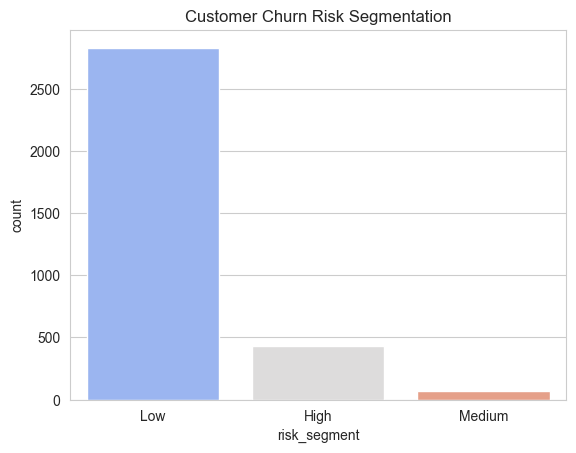

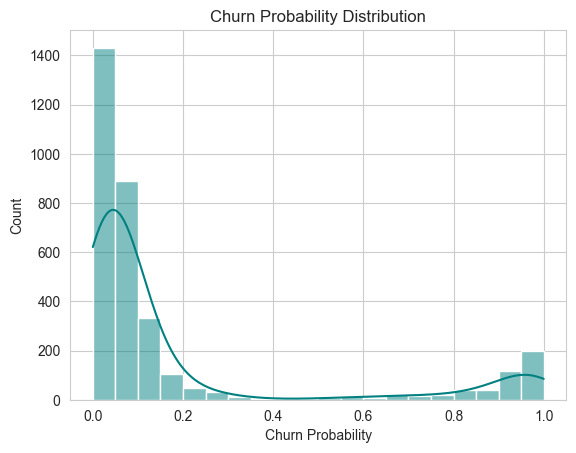

In [19]:
# 13. VISUALIZE RISK SEGMENTATION

sns.countplot(x='risk_segment', data=df_churn, palette='coolwarm')
plt.title("Customer Churn Risk Segmentation")
plt.show()

sns.histplot(df_churn['churn_probability'], bins=20, kde=True, color='teal')
plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.show()

In [20]:
# EXPORT FOR POWER BI

df_churn.to_csv("churn_final_with_prediction.csv", index=False)
print("File exported: churn_final_with_predictions.csv ")

File exported: churn_final_with_predictions.csv 


In [21]:
# 14. SUMMARY & INSIGHTS

print("SUMMARY & INSIGHTS:\n")
print("""
1. Random Forest is the best performing model with 97% accuracy and strong balance between
   precision and recall, making it reliable for churn prediction.

2. Top features influencing churn include:
   - total_day_charge, total_eve_charge, customer_service_calls, international_plan, etc.
   (See feature importance chart above)

3. Churn risk segmentation:
   - Low risk (<0.3 probability): ~stable customers
   - Medium risk (0.3-0.7): ~monitor & engage
   - High risk (>0.7): ~prioritize for retention

""")

print("NEXT STEPS:\n")
print("""
1. Focus retention campaigns on High and Medium risk customers.
2. Monitor feature changes over time to update predictive model.
3. Use churn_probability and risk_segment for targeted marketing and personalized interventions.
4. Re-train model periodically as new data comes in to maintain accuracy.
""")

SUMMARY & INSIGHTS:


1. Random Forest is the best performing model with 97% accuracy and strong balance between
   precision and recall, making it reliable for churn prediction.

2. Top features influencing churn include:
   - total_day_charge, total_eve_charge, customer_service_calls, international_plan, etc.
   (See feature importance chart above)

3. Churn risk segmentation:
   - Low risk (<0.3 probability): ~stable customers
   - Medium risk (0.3-0.7): ~monitor & engage
   - High risk (>0.7): ~prioritize for retention


NEXT STEPS:


1. Focus retention campaigns on High and Medium risk customers.
2. Monitor feature changes over time to update predictive model.
3. Use churn_probability and risk_segment for targeted marketing and personalized interventions.
4. Re-train model periodically as new data comes in to maintain accuracy.

